# Capítulo 11: Intervalos de confiança

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

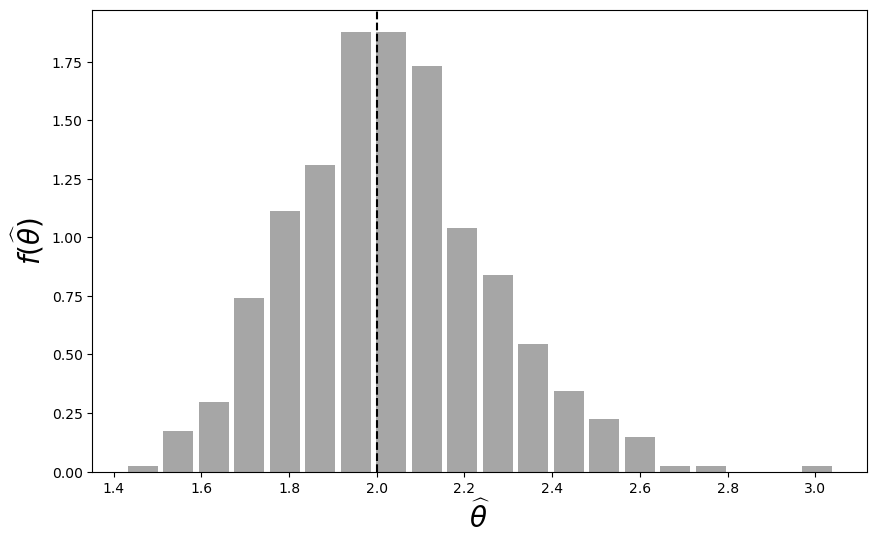

In [1]:
# Pág. 309
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2011)

theta = 2 # parâmetro do modelo exponencial
n = 100 # tamanho da amostra
ns = 500 # número de amostras
v_theta_hat = []
for s in range(0,ns):
    # sorteia uma amostra de tamanho n
    x = np.random.exponential(1/theta, n)
    # usa o estimador da exponencial
    theta_hat = n/np.sum(x)
    # armazena o valor estimado
    v_theta_hat.append(theta_hat)

# mostra os resultados da simulação
plt.figure(figsize=(10,6))
plt.hist(x=v_theta_hat, bins=20,color='gray', 
         alpha=0.7, rwidth=0.85, density = True)
plt.xlabel(r'$\widehat{\theta}$', fontsize=20)
plt.ylabel(r'$f(\widehat{\theta})$', fontsize=20)
plt.axvline(x=theta, color='k', linestyle='--')
plt.show(True)

Nível de confiança: 0.95
Fração de intervalos que contêm a média: 0.95


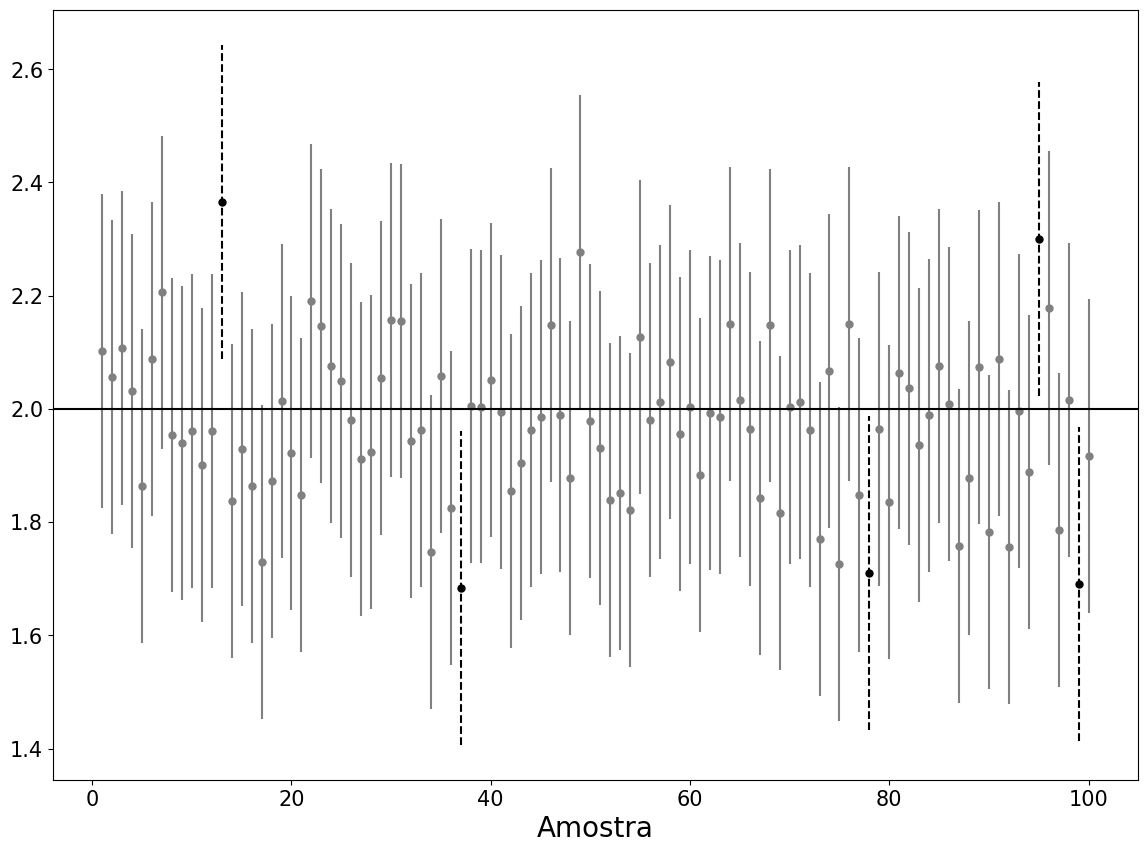

In [2]:
# Pág. 313
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
np.random.seed(10)

n = 50 # tamanho da amostra
Ns = 100 # número de intervalos
mu = 2 # média populacional
sigma = 1 # desvio padrão populacional
confidence = 0.95 # nível de confiança
alpha = 1 - confidence
# obtém zalpha/2 (tabelado)
zalpha = abs(scipy.stats.norm.ppf(1 - alpha/2.0)) 
c = 0 # conta o número de intervalos que contém a média
plt.figure(figsize=(14,10))
for s in range(1,Ns+1):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n) 
    # calcula o intervalo inferior
    IC1 = np.mean(x) - zalpha*sigma/np.sqrt(n) 
    # calcula o intervalo superior
    IC2 = np.mean(x) + zalpha*sigma/np.sqrt(n) 
    if(mu > IC1 and mu < IC2):
        c =  c + 1
        # mostra o intervalo que contém a média
        plt.vlines(s, ymin=IC1, ymax=IC2, color = 'gray')
        plt.plot(s,np.mean(x), 'o', color = 'gray', 
                 markersize=5)
    else:
        # mostra o intervalo que não contem a média
        plt.vlines(s, ymin=IC1, ymax=IC2, 
                   color = 'black', linestyles = 'dashed')
        plt.plot(s,np.mean(x), 'o', color = 'black',
                 markersize=5)

print('Nível de confiança:', confidence)
print('Fração de intervalos que contêm a média:', c/Ns)
# mostra a média populacional
plt.axhline(y = mu, color = 'black') 
plt.xlabel('Amostra', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [3]:
# Pág. 314
import scipy.stats
confidence = 0.95
alpha = 1 - confidence
z = scipy.stats.norm.ppf(1 - alpha/2)
print(z)

1.959963984540054


In [4]:
# Pág. 316
import scipy.stats
n = 16
alpha = 0.05
df = n-1 #graus de liberdade
talpha = scipy.stats.t.ppf(1-(alpha), df)
print(talpha)

1.7530503556925727


In [5]:
# Pág. 317
import scipy.stats
import numpy as np

Xn = 39.3 # média amostral
s = 2.6 # desvio padrão amostral
n = 15 # tamanho da amostra
confidence =0.9 # nível de confiança
alpha = 1 - confidence
df = 14 #grau de liberdade
talpha = scipy.stats.t.ppf(1-(alpha/2), df)
IC1 = Xn - talpha*s/np.sqrt(n)
IC2 = Xn + talpha*s/np.sqrt(n)
print('IC:[', IC1,';', IC2,']')

IC:[ 38.1176023639505 ; 40.48239763604949 ]


In [6]:
# Pág. 319
import scipy.stats
import numpy as np

def confidence_interval(Xn, n, confidence = 0.95, 
                       sigma = -1, s = -1):
    alpha = 1 - confidence
    zalpha = abs(scipy.stats.norm.ppf(alpha/2))
    if(sigma != -1): # se a variância é conhecida
        IC1 = Xn - zalpha*sigma/np.sqrt(n)
        IC2 = Xn + zalpha*sigma/np.sqrt(n)
    else: # se a variância é desconhecida
        if(n >= 50): # se o tamanho da amostra > 50
            # Use a distribuição normal
            IC1 = Xn - zalpha*s/np.sqrt(n)
            IC2 = Xn + zalpha*s/np.sqrt(n)
        else: # se o tamanho da amostra é < 50
            # Use a distribuição t de Student
            talpha = scipy.stats.t.ppf((1 + confidence) / 2., n-1)
            IC1 = Xn - talpha*s/np.sqrt(n)
            IC2 = Xn + talpha*s/np.sqrt(n)
    # retorna o intervalo de confiança
    return [IC1, IC2]

In [7]:
# Pág. 319
Xn = 39.3 # média amostral
s = 2.6 # desvio padrão amostral
n = 15 # tamanho da amostra
confidence = 0.9 # nível de confiança
# chama a função para calcular o intervalo
IC = confidence_interval(Xn,n, confidence, -1, s)
print('Confidence interval:', IC)

Confidence interval: [np.float64(38.1176023639505), np.float64(40.48239763604949)]


In [8]:
# Pág. 319
import scipy.stats
import numpy as np

def confidence_interval_data(X, confidence = 0.95, 
                            sigma = -1):
    # função para calcular o desvio padrão amostral
    def S(X): 
        s = 0
        # calcula o desvio padrão amostral
        for i in range(0,len(X)):
            s = s + (X[i] - np.mean(X))**2
        s = np.sqrt(s/(len(X)-1))
        return s
    n = len(X) # número de elementos na amostra
    Xs = np.mean(X) # média amostral
    s = S(X) # desvio padrão amostral
    zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2))
    if(sigma != -1): # se a variância é conhecida
        IC1 = Xs - zalpha*sigma/np.sqrt(n)
        IC2 = Xs + zalpha*sigma/np.sqrt(n)
    else: # se a variância é desconhecida
        if(n >= 50): # se o tamanho da amostra é > 50
            # Usa a distribuição normal
            IC1 = Xs - zalpha*s/np.sqrt(n)
            IC2 = Xs + zalpha*s/np.sqrt(n)
        else: # se o tamanho da amostra é < 50
            # Usa a distribuição t de Student
            talpha = scipy.stats.t.ppf((1 + confidence) / 2., n-1)
            IC1 = Xs - talpha*s/np.sqrt(n)
            IC2 = Xs + talpha*s/np.sqrt(n)
    return [IC1, IC2]

In [9]:
# Pág. 320
X = [1,3,4,1,2,3,4,5,3]
confidence = 0.95
IC = confidence_interval_data(X, confidence)
print('IC:', IC)

IC: [np.float64(1.840252369997625), np.float64(3.9375254077801527)]


IC: [ 9.753046170172585 10.358926240498356 ]


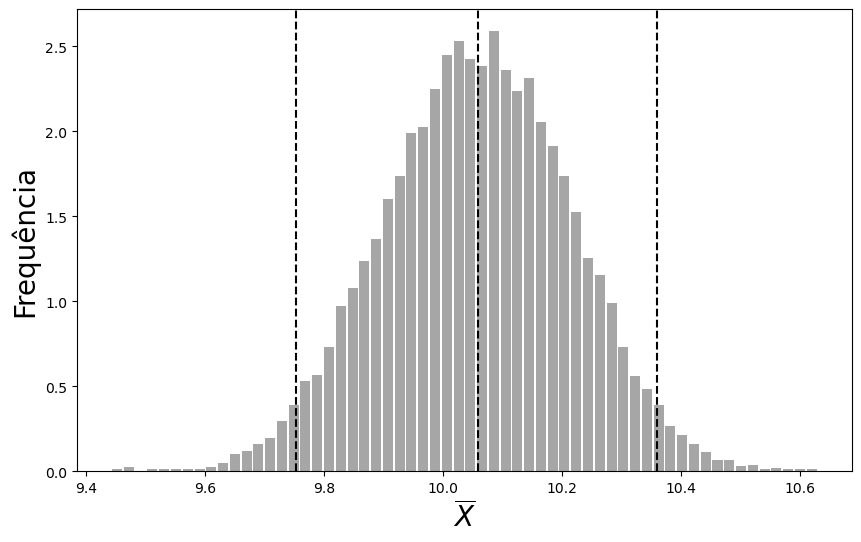

In [10]:
# Pág. 324
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2011)

# gera os dados que serão amostrados
# esses dados podem ser simulados ou
# lidos de um arquivo
mu = 10 # média populacional
sigma = 5 # desvio padrão
n = 1000 # tamanho da amostra
X = np.random.normal(mu, sigma, n)
#X = np.random.exponential(scale=mu, size = n)

#Bootstrapping: sorteia ns amostras
ns = 10000
theta_hat = []
for i in range(0,ns):
    # amostra n elementos de X
    s = np.random.choice(X, n, replace=True)
    theta_hat.append(np.mean(s))

# calcula a mediana
median = np.percentile(theta_hat, 50)
# calcula o intervalo de confiança
confidence = 95
alpha = 100-confidence
lower_ci = np.percentile(theta_hat, alpha/2)
upper_ci = np.percentile(theta_hat, 100-alpha/2)
print('IC: [',lower_ci, upper_ci,']')
# mostra os resultados
plt.figure(figsize=(10,6))
plt.hist(x=theta_hat, bins='auto',color='gray', alpha=0.7, rwidth=0.85, density = True)
plt.axvline(median, linestyle="--", color="black")
plt.axvline(lower_ci, linestyle="--", color="black")
plt.axvline(upper_ci, linestyle="--", color="black")
plt.xlabel(r'$\overline{X}$', fontsize=20)
plt.ylabel('Frequência', fontsize=20)
plt.show(True) 

In [11]:
# Pág. 326
import scipy.stats
import numpy as np
Xn = 8
sigma = 1
n = 100
confidence =0.99
alpha = 1 - confidence
zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2.))
IC1 = Xn - zalpha*sigma/np.sqrt(n)
IC2 = Xn + zalpha*sigma/np.sqrt(n)
print('IC:[', IC1,';', IC2,']')

IC:[ 7.74241706964511 ; 8.25758293035489 ]


In [12]:
# Pág. 327
import matplotlib.pyplot as plt
from sklearn import datasets
import scipy.stats
import numpy as np

def confidence_interval_data(X, confidence = 0.95, 
                            sigma = -1):
    # função que calcula o desvio padrão amostral
    def S(X): 
        s = 0
        for i in range(0,len(X)):
            s = s + (X[i] - np.mean(X))**2
        s = np.sqrt(s/(len(X)-1))
        return s
    n = len(X) # número de elementos na amostra
    Xs = np.mean(X) # média amostral
    s = S(X) # desvio padrão amostral
    zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2))
    if(sigma != -1): # se a variância é conhecida
        IC1 = Xs - zalpha*sigma/np.sqrt(n)
        IC2 = Xs + zalpha*sigma/np.sqrt(n)
    else: # se a variância é desconhecida
        if(n >= 50): # se o tamanho da amostra é > 50
            # Usa a distribuição normal
            IC1 = Xs - zalpha*s/np.sqrt(n)
            IC2 = Xs + zalpha*s/np.sqrt(n)
        else: # se o tamanho da amostra é < 50
            # Use a distribuição t de Student
            talpha = scipy.stats.t.ppf((1 + confidence) / 2., n-1)
            IC1 = Xs - talpha*s/np.sqrt(n)
            IC2 = Xs + talpha*s/np.sqrt(n)
    return [IC1, IC2]

# leitura dos dados
iris = datasets.load_iris()
variables = iris.feature_names
species = iris.target_names
print('Variáveis:', variables)
# o comprimento da pétala é a terceira variável
data = iris.data[:,2]  
y = iris.target

for c in range(0,3):
    print('*****************')
    print('Espécie:', species[c])
    X = data[y == c]
    IC = confidence_interval_data(X, confidence=0.9)
    print('IC:', IC)

Variáveis: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
*****************
Espécie: setosa
IC: [np.float64(1.4216027273275496), np.float64(1.5023972726724508)]
*****************
Espécie: versicolor
IC: [np.float64(4.15069051580011), np.float64(4.369309484199889)]
*****************
Espécie: virginica
IC: [np.float64(5.423619673858185), np.float64(5.680380326141816)]


In [13]:
# Pág. 328
import numpy as np
from sklearn import datasets
np.random.seed(2011)

iris = datasets.load_iris()
variables = iris.feature_names
species = iris.target_names
print('Variáveis:', variables)
# o comprimento da pétala é a terceira variável
data = iris.data[:,2]  
y = iris.target

for c in range(0,3): # para cada espécie da Iris
    print('*****************')
    print('Espécie:', species[c])
    X = data[y == c]
    n = X.size

    #Bootstrapping: sorteia ns amostras
    ns = 10000
    theta_hat = []
    for i in range(0,ns):
        # amostra n elementos da população
        s = np.random.choice(X, n, replace=True)
        theta_hat.append(np.mean(s))

    # calcula a mediana
    median = np.percentile(theta_hat, 50)
    # calcula o intervalo de confiança
    confidence = 95
    alpha = 100-confidence
    lower_ci = np.percentile(theta_hat, alpha/2)
    upper_ci = np.percentile(theta_hat, 100-alpha/2)
    print('IC: [',lower_ci, upper_ci,']')

Variáveis: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
*****************
Espécie: setosa
IC: [ 1.4140000000000001 1.5100000000000002 ]
*****************
Espécie: versicolor
IC: [ 4.128000000000001 4.386 ]
*****************
Espécie: virginica
IC: [ 5.405999999999999 5.704000000000001 ]


In [14]:
# Pág. 331
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# amostra
X = [3200, 3050, 3400, 3180, 3300, 3120, 
     3280, 3350, 3250, 3100]
n = len(X)
confidence = 90

#Bootstrapping: sorteia ns amostras
ns = 10000
theta_hat = []
for i in range(0,ns):
    # amostra n elementos de X
    s = np.random.choice(X, n, replace=True)
    theta_hat.append(np.mean(s))

# calcula a mediana
median = np.percentile(theta_hat, 50)
# calcula o intervalo de confiança
alpha = 100-confidence
lower_ci = np.percentile(theta_hat, alpha/2)
upper_ci = np.percentile(theta_hat, 100-alpha/2)
print('IC: [',lower_ci, upper_ci,']')

IC: [ 3167.0 3279.0 ]
